In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!git config --global user.email "spoorthyece@gmail.com"
!git config --global user.name "Spoorthy2001"

# Hence Proved — 02 — Torque
## τ = r × F × sin(θ)
**Author:** Spoorthy J  
**Date:** 8th May 2026  
**Series:** Hence Proved — Physics through Machine Learning

## Problem Statement
Can I teach a machine how to do vector multiplication with physics entities to calculate torque

## Physics Context
Torque : τ = r × F × sin(θ)

| Variable | Meaning | Unit |
|---|---|---|
| r | moment arm | m |
| F | force applied | N |
| θ | angle | ° |
| τ | torque (target) | Nm |

## Key Insight

F = ma was direct — the model only needed
to learn a best fit line.

τ = r × F × sin(θ) is harder because sin(θ)
makes the relationship non-linear and cyclical.
Torque doesn't grow steadily — it rises, peaks,
falls and reverses with every rotation.

sin(θ) is not a number — it's a wave.

At θ = 0°  → sin(0)   =  0  → zero torque
At θ = 90° → sin(90)  =  1  → maximum torque
At θ = 180°→ sin(180) =  0  → zero torque again
At θ = 270°→ sin(270) = -1  → negative torque (reverse)

Linear Regression will fail here.
That failure is the point.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)

In [8]:
n = 1000

# Wrench length — 0.1m to 1.0m (10cm to 1m)
r = np.random.uniform(0.1, 1.0, n)

# Force applied — 10N to 500N
F = np.random.uniform(10, 500, n)

# Angle of push — 0° to 360°
theta = np.random.uniform(0, 360, n)
theta_rad = np.radians(theta)

# τ = r × F × sin(θ) + noise
noise = np.random.normal(0, 2, n)
torque = (r * F * np.sin(theta_rad)) + noise

(1000, 4)


,r_m,F_N,theta_deg,torque_Nm
0,0.4371,100.72,94.21,46.0220
1,0.9556,275.53,88.91,264.4963
2,0.7588,437.74,326.25,-183.1616
3,0.6388,368.79,89.84,232.8476
4,0.2404,405.21,97.90,98.9193
5,0.2404,332.80,273.38,-79.3425
6,0.1523,349.22,161.91,15.7767
7,0.8796,426.11,279.62,-369.2325
8,0.6410,132.34,23.53,30.3161
9,0.7373,249.82,175.53,15.1859


In [33]:
df = pd.DataFrame({
    'r_m'       : np.round(r, 4),
    'F_N'       : np.round(F, 2),
    'theta_deg' : np.round(theta, 2),
    'torque_Nm' : np.round(torque, 4)
})

df['sine_theta'] = np.sin(np.radians(df['theta_deg']))

print(df.shape)
df.head(10)

(1000, 5)


,r_m,F_N,theta_deg,torque_Nm,sine_theta
0,0.4371,100.72,94.21,46.0220,0.997302
1,0.9556,275.53,88.91,264.4963,0.999819
2,0.7588,437.74,326.25,-183.1616,-0.555570
3,0.6388,368.79,89.84,232.8476,0.999996
4,0.2404,405.21,97.90,98.9193,0.990509
5,0.2404,332.80,273.38,-79.3425,-0.998260
6,0.1523,349.22,161.91,15.7767,0.310511
7,0.8796,426.11,279.62,-369.2325,-0.985938
8,0.6410,132.34,23.53,30.3161,0.399229
9,0.7373,249.82,175.53,15.1859,0.077937


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   r_m         1000 non-null   float64
 1   F_N         1000 non-null   float64
 2   theta_deg   1000 non-null   float64
 3   torque_Nm   1000 non-null   float64
 4   sine_theta  1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


In [35]:
df.describe()

,r_m,F_N,theta_deg,torque_Nm,sine_theta
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.541232,258.438390,180.86595,-0.901968,-0.008513
std,0.262924,143.172978,104.64264,126.338223,0.703128
min,0.104200,11.580000,0.00000,-438.006500,-0.999973
25%,0.312375,128.127500,94.08250,-57.910525,-0.724472
50%,0.547100,264.180000,180.22000,-0.762700,-0.003840
75%,0.769925,382.627500,273.27500,54.053325,0.683432
max,0.999700,499.710000,359.22000,443.951100,0.999996


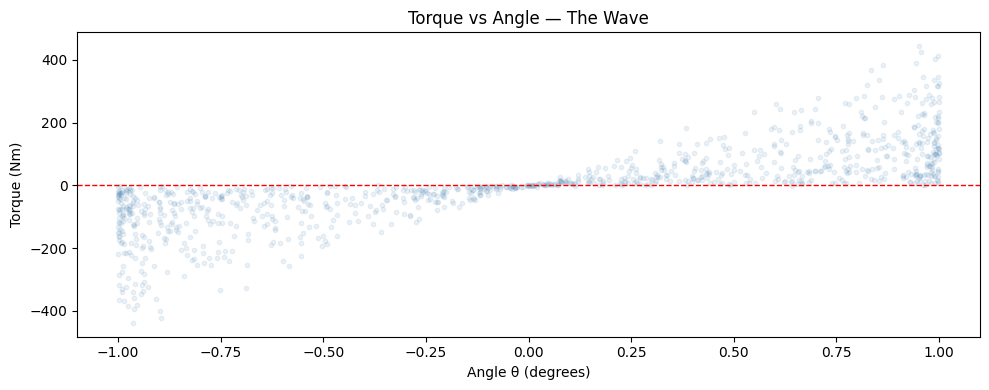

In [36]:
plt.figure(figsize=(10, 4))
plt.scatter(df['sine_theta'], df['torque_Nm'], alpha=0.1, color='steelblue', s=10)
plt.xlabel("Angle θ (degrees)")
plt.ylabel("Torque (Nm)")
plt.title("Torque vs Angle — The Wave")
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [15]:
# plt.figure(figsize=(10,4))
# plt.scatter(df['r_m'], df['torque_Nm'], color='red')
# plt.xlabel("Moment Arm (m)")
# plt.ylabel("Torque (Nm)")
# plt.title("Torque vs Moment Arm")
# plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
# plt.tight_layout()
# plt.show()

In [17]:
# sns.pairplot(df)
# plt.show()

In [19]:
# Distributions
# df.hist(figsize=(10, 4), bins=30, color='steelblue', edgecolor='black')
# plt.suptitle("Feature Distributions")
# plt.tight_layout()
# plt.show()

In [38]:
#Correlation

df.corr(numeric_only=True)

#resultant matrix says, r and F have near zero correlation with torque.
#But in reality, A longer wrench and more force should produce more torque.


,r_m,F_N,theta_deg,torque_Nm,sine_theta
r_m,1.000000,0.029310,0.014515,0.006231,0.019977
F_N,0.029310,1.000000,0.027263,-0.024303,-0.013873
theta_deg,0.014515,0.027263,1.000000,-0.615258,-0.769597
torque_Nm,0.006231,-0.024303,-0.615258,1.000000,0.785434
sine_theta,0.019977,-0.013873,-0.769597,0.785434,1.000000


# Iteration 01 - Linear Regression
##

In [39]:
X_1 = df[['r_m', 'F_N', 'sine_theta']]
y_1 = df['torque_Nm']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)
y_pred_1 = model_1.predict(X_test_1)

mae_1 = mean_absolute_error(y_test_1, y_pred_1)
r2_1 = r2_score(y_test_1, y_pred_1)

print("--- Model 1 --- Raw Features ---")
print(f"R²  : {r2_1:.4f}")
print(f"MAE : {mae_1:.4f}")
print(f"\nCoefficients:")
for feat, coef in zip(X_1.columns, model_1.coef_):
    print(f"  {feat} : {coef:.4f}")
print(f"  intercept : {model_1.intercept_:.4f}")


--- Model 1 --- Raw Features ---
R²  : 0.5821
MAE : 55.0712

Coefficients:
  r_m : 1.4259
  F_N : -0.0008
  sine_theta : 144.7876
  intercept : 1.0765


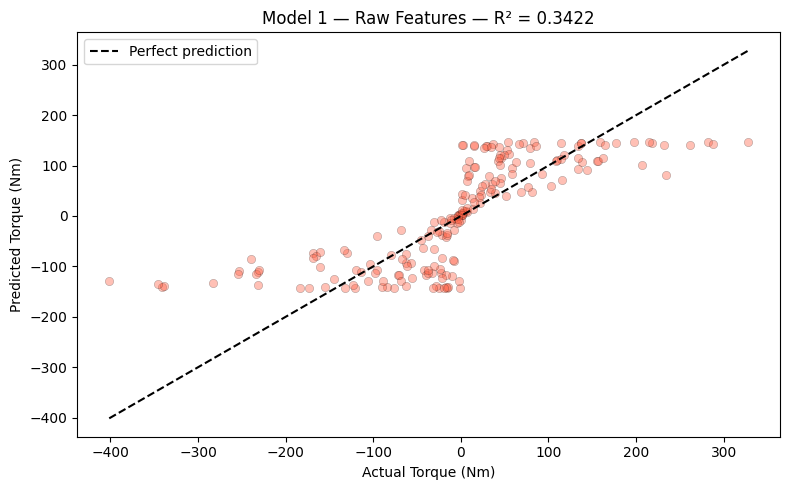

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_1, y_pred_1, alpha=0.4, color='tomato', edgecolors='black', linewidths=0.3)
plt.plot([y_test_1.min(), y_test_1.max()],[y_test_1.min(), y_test_1.max()],'k--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Torque (Nm)")
plt.ylabel("Predicted Torque (Nm)")
plt.title(f"Model 1 — Raw Features — R² = 0.3422")
plt.legend()
plt.tight_layout()
plt.show()

# Iteration 02 - Feature Engineering

#### Use the existing columns to create a new feature, to replicate multplicative relation

In [42]:
df['r_x_F_x_sin_theta'] = df['r_m'] * df['F_N'] * df['sine_theta']
df.head()

,r_m,F_N,theta_deg,torque_Nm,sine_theta,r_x_F_x_sin_theta
0,0.4371,100.72,94.21,46.0220,0.997302,43.905919
1,0.9556,275.53,88.91,264.4963,0.999819,263.248824
2,0.7588,437.74,326.25,-183.1616,-0.555570,-184.536604
3,0.6388,368.79,89.84,232.8476,0.999996,235.582133
4,0.2404,405.21,97.90,98.9193,0.990509,96.487987


In [45]:
# Model 02

X_2 = df[['r_x_F_x_sin_theta']]
y_2 = df['torque_Nm']

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)
y_pred_2 = model_2.predict(X_test_2)

mae_2 = mean_absolute_error(y_test_2, y_pred_2)
r2_2 = r2_score(y_test_2, y_pred_2)

print("--- Model 2 --- Feature Engineering ---")
print(f"Coefficient : {model_2.coef_[0]:.4f}")
print(f"Intercept   : {model_2.intercept_:.4f}")
print(f"R²  : {r2_2:.4f}")
print(f"MAE : {mae_2:.4f}")

--- Model 2 --- Feature Engineering ---
Coefficient : 0.9995
Intercept   : 0.0246
R²  : 0.9997
MAE : 1.7320


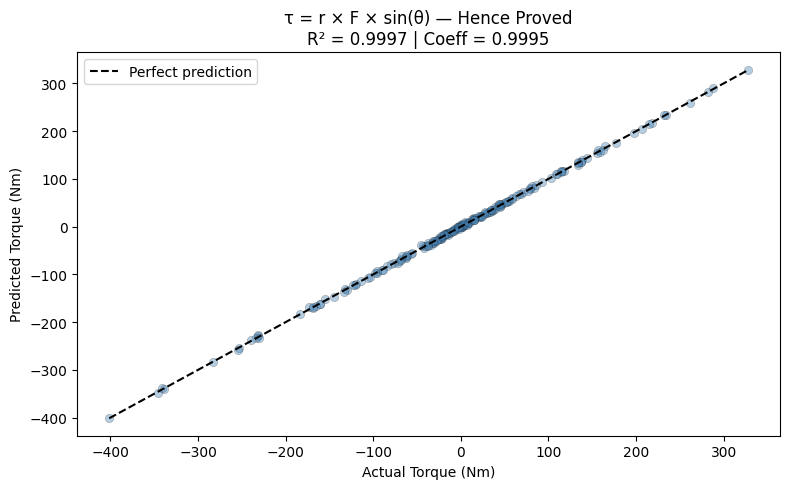

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_2, y_pred_2, alpha=0.4,
            color='steelblue', edgecolors='black', linewidths=0.3)
plt.plot([y_test_2.min(), y_test_2.max()],
         [y_test_2.min(), y_test_2.max()],
         'k--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Torque (Nm)")
plt.ylabel("Predicted Torque (Nm)")
plt.title("τ = r × F × sin(θ) — Hence Proved\nR² = 0.9997 | Coeff = 0.9995")
plt.legend()
plt.tight_layout()
plt.show()

# HENCE PROVED !!!




# Additional try using Polynomial Regression

In [56]:
from sklearn.preprocessing import PolynomialFeatures

X_poly = df[['r_m', 'F_N', 'sine_theta']]
y_poly = df['torque_Nm']

poly = PolynomialFeatures(degree=3)
X_transformed = poly.fit_transform(X_poly)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_transformed, y_poly, test_size=0.2, random_state=42)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)
y_pred_poly = model_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print("Mean absolute error :: ", mae_poly)
print("R2 score :: ", r2_poly)

Mean absolute error ::  1.7924253100495222
R2 score ::  0.9996472268474764


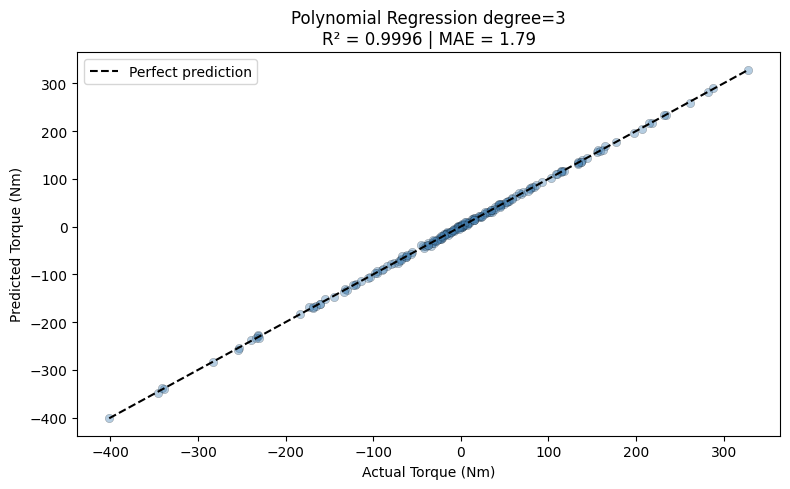

In [57]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_poly, y_pred_poly, alpha=0.4,
            color='steelblue', edgecolors='black', linewidths=0.3)
plt.plot([y_test_poly.min(), y_test_poly.max()],
         [y_test_poly.min(), y_test_poly.max()],
         'k--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Torque (Nm)")
plt.ylabel("Predicted Torque (Nm)")
plt.title("Polynomial Regression degree=3\nR² = 0.9996 | MAE = 1.79")
plt.legend()
plt.tight_layout()
plt.show()

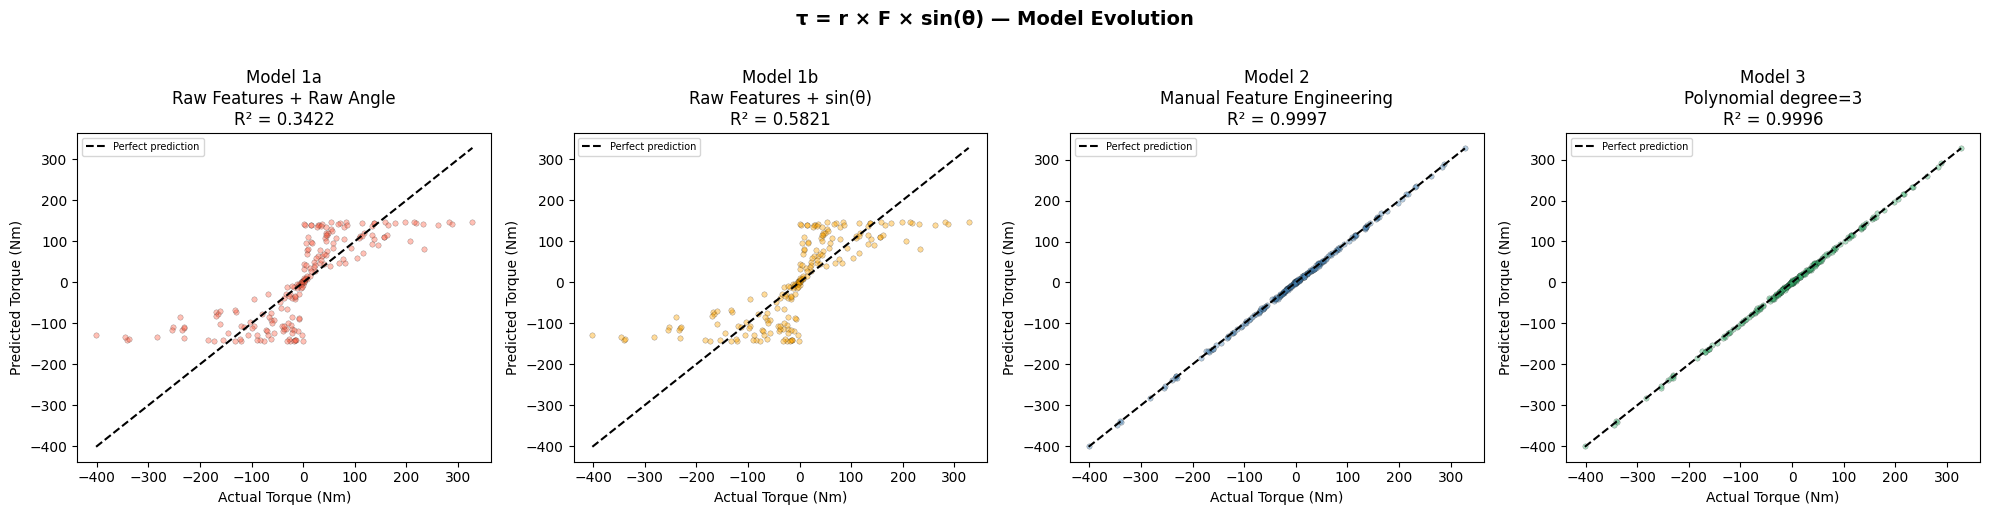

In [59]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models = [
    (y_test_1, y_pred_1, "Model 1a\nRaw Features + Raw Angle", 0.3422, "tomato"),
    (y_test_1, y_pred_1, "Model 1b\nRaw Features + sin(θ)", 0.5821, "orange"),
    (y_test_2, y_pred_2, "Model 2\nManual Feature Engineering", 0.9997, "steelblue"),
    (y_test_poly, y_pred_poly, "Model 3\nPolynomial degree=3", 0.9996, "mediumseagreen"),
]

for ax, (actual, predicted, title, r2, color) in zip(axes, models):
    ax.scatter(actual, predicted, alpha=0.4, color=color,
               edgecolors='black', linewidths=0.3, s=15)
    ax.plot([actual.min(), actual.max()],
            [actual.min(), actual.max()],
            'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel("Actual Torque (Nm)")
    ax.set_ylabel("Predicted Torque (Nm)")
    ax.set_title(f"{title}\nR² = {r2}")
    ax.legend(fontsize=7)

plt.suptitle("τ = r × F × sin(θ) — Model Evolution",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(model_poly, 'torque_model.joblib')

print("Saved")